In [1]:
import pandas as pd

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('../../datasets/winequality-red.csv')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
df.shape

(1599, 12)

In [4]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3], dtype=int64)

array([[<AxesSubplot:title={'center':'quality'}>]], dtype=object)

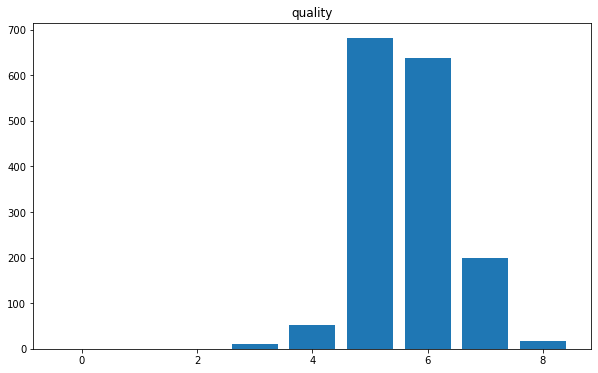

In [5]:
df.hist(column='quality', figsize=(10,6), bins=np.arange(10) - 0.5, grid=False, rwidth=0.8)

In [6]:
# Para transformar a coluna quality em rótulo
from sklearn import preprocessing

# quality = ["3", "4", "5", "6", "7", "8"]
# label_encoding = preprocessing.LabelEncoder()
# label_encoding = label_encoding.fit(quality)

# df['quality'] = label_encoding.transform(df['quality'].astype(str))

In [7]:
from sklearn.model_selection import train_test_split

X = df.drop(['quality'], axis=1)
Y = df['quality']

x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)

In [8]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(max_depth=2).fit(x_train, y_train)

In [9]:
y_pred = dt_model.predict(x_test)

In [10]:
pred_results = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})

In [11]:
pred_results.head()

,y_test,y_pred
1292,6,6
724,4,6
389,7,5
1133,7,6
130,5,5


In [12]:
df_crosstab = pd.crosstab(pred_results.y_pred, pred_results.y_test)
df_crosstab

y_test,3,4,5,6,7,8
y_pred,,,,,,
5,3,7,116,56,4,0
6,0,3,28,68,33,2


In [13]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')

print("Acurácia : ", accuracy)
print("Precisão : ", precision)
print("Recall : ", recall)

Acurácia :  0.575
Precisão :  0.575
Recall :  0.575


In [15]:
from sklearn import tree
text_representation = tree.export_text(dt_model)
print(text_representation)

|--- feature_10 <= 10.25
|   |--- feature_6 <= 51.50
|   |   |--- class: 5
|   |--- feature_6 >  51.50
|   |   |--- class: 5
|--- feature_10 >  10.25
|   |--- feature_10 <= 11.55
|   |   |--- class: 6
|   |--- feature_10 >  11.55
|   |   |--- class: 6



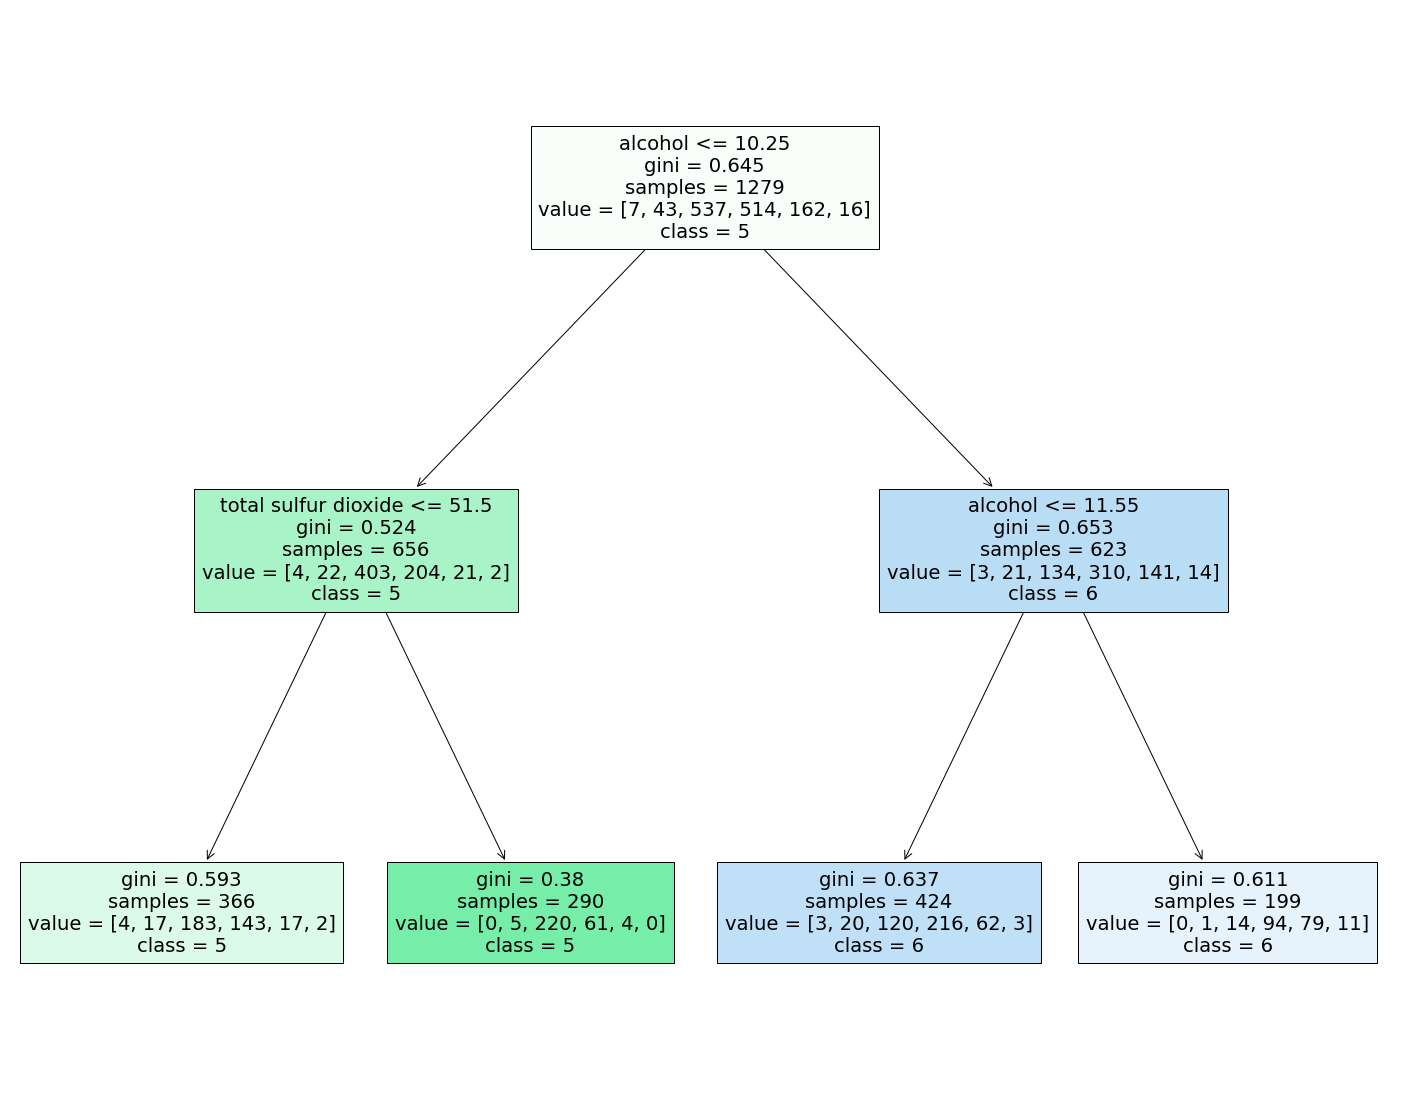

In [16]:
import matplotlib.pyplot as plt

dt_feature_names = list(X.columns)
dt_target_names = [str(s) for s in sorted(Y.unique())]

fig = plt.figure(figsize=(25,20))
plt = tree.plot_tree(dt_model, feature_names=dt_feature_names, class_names=dt_target_names, filled=True)

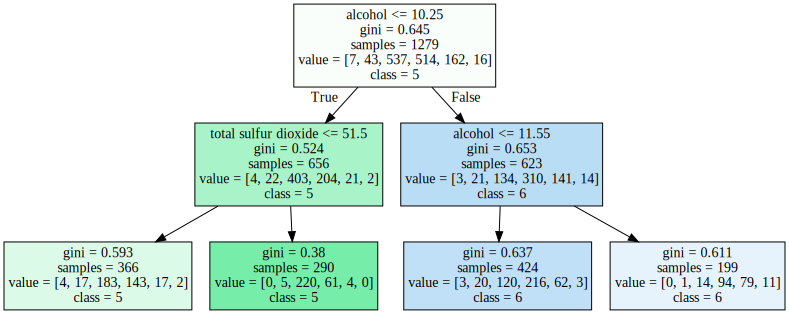

In [17]:
import os
os.environ["PATH"] += os.pathsep + 'D:/Program Files/Graphviz/bin/'

# Para instalar wordcloud, abra um terminal e execute [pip install wordcloud]
import graphviz

dot_data = tree.export_graphviz(dt_model, out_file=None, feature_names=dt_feature_names, class_names=dt_target_names, \
                                filled=True)

graph = graphviz.Source(dot_data, format="png") 
graph

In [18]:
from sklearn.model_selection import GridSearchCV

parameters = {'max_depth': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]}

grid_search = GridSearchCV(DecisionTreeClassifier(), parameters, cv=3, return_train_score=True)
grid_search.fit(x_train, y_train)

grid_search.best_params_

{'max_depth': 14}

In [19]:
for i in range(15):
    print('Parameters: ', grid_search.cv_results_['params'][i])
    print('Mean Test Score: ', grid_search.cv_results_['mean_test_score'][i])
    print('Rank: ', grid_search.cv_results_['rank_test_score'][i])

Parameters:  {'max_depth': 2}
Mean Test Score:  0.5535709704492895
Rank:  15
Parameters:  {'max_depth': 3}
Mean Test Score:  0.560591234107743
Rank:  14
Parameters:  {'max_depth': 4}
Mean Test Score:  0.5738969335136502
Rank:  5
Parameters:  {'max_depth': 5}
Mean Test Score:  0.5715311907877135
Rank:  7
Parameters:  {'max_depth': 6}
Mean Test Score:  0.5699845704463575
Rank:  9
Parameters:  {'max_depth': 7}
Mean Test Score:  0.5676499800258746
Rank:  11
Parameters:  {'max_depth': 8}
Mean Test Score:  0.5754655437176794
Rank:  4
Parameters:  {'max_depth': 9}
Mean Test Score:  0.5684067977995477
Rank:  10
Parameters:  {'max_depth': 10}
Mean Test Score:  0.5731016334802989
Rank:  6
Parameters:  {'max_depth': 11}
Mean Test Score:  0.5676224926975331
Rank:  13
Parameters:  {'max_depth': 12}
Mean Test Score:  0.5676279901632014
Rank:  12
Parameters:  {'max_depth': 13}
Mean Test Score:  0.5707487181742551
Rank:  8
Parameters:  {'max_depth': 14}
Mean Test Score:  0.5816923398313377
Rank:  1
Pa

In [20]:
dt_model = DecisionTreeClassifier(max_depth = grid_search.best_params_['max_depth']).fit(x_train, y_train)

In [21]:
y_pred = dt_model.predict(x_test)

In [22]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')

print("Acurácia : ", accuracy)
print("Precisão : ", precision)
print("Recall : ", recall)

Acurácia :  0.628125
Precisão :  0.628125
Recall :  0.628125


In [23]:
pred_results = pd.DataFrame({'y_test': y_test, 'y_pred': y_pred})

In [24]:
pred_results.head()

,y_test,y_pred
1292,6,6
724,4,6
389,7,5
1133,7,6
130,5,5


In [25]:
df_crosstab = pd.crosstab(pred_results.y_pred, pred_results.y_test)
df_crosstab

y_test,3,4,5,6,7,8
y_pred,,,,,,
4,1,1,7,3,2,0
5,1,4,103,33,4,0
6,1,4,32,80,14,0
7,0,1,2,8,15,0
8,0,0,0,0,2,2


In [26]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

In [27]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')

print("Acurácia : ", accuracy)
print("Precisão : ", precision)
print("Recall : ", recall)

Acurácia :  0.628125
Precisão :  0.628125
Recall :  0.628125


In [28]:
from sklearn import tree
text_representation = tree.export_text(dt_model)
print(text_representation)

|--- feature_10 <= 10.25
|   |--- feature_6 <= 51.50
|   |   |--- feature_9 <= 0.58
|   |   |   |--- feature_10 <= 9.05
|   |   |   |   |--- feature_2 <= 0.55
|   |   |   |   |   |--- feature_9 <= 0.53
|   |   |   |   |   |   |--- class: 4
|   |   |   |   |   |--- feature_9 >  0.53
|   |   |   |   |   |   |--- class: 6
|   |   |   |   |--- feature_2 >  0.55
|   |   |   |   |   |--- class: 5
|   |   |   |--- feature_10 >  9.05
|   |   |   |   |--- feature_5 <= 11.50
|   |   |   |   |   |--- feature_3 <= 4.80
|   |   |   |   |   |   |--- feature_6 <= 10.00
|   |   |   |   |   |   |   |--- feature_4 <= 0.06
|   |   |   |   |   |   |   |   |--- feature_3 <= 1.70
|   |   |   |   |   |   |   |   |   |--- class: 5
|   |   |   |   |   |   |   |   |--- feature_3 >  1.70
|   |   |   |   |   |   |   |   |   |--- class: 4
|   |   |   |   |   |   |   |--- feature_4 >  0.06
|   |   |   |   |   |   |   |   |--- class: 6
|   |   |   |   |   |   |--- feature_6 >  10.00
|   |   |   |   |   |   |   |--- 

In [29]:
from sklearn.model_selection import GridSearchCV

a = np.arange(40)
b = [0, 1, 2]
md = np.array(sorted(set(a) - set(b)))

parameters = {'criterion': ['gini', 'entropy'], \
              'max_depth': md, \
              'max_features': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]}

grid_search = GridSearchCV(DecisionTreeClassifier(), parameters, cv=3, return_train_score=True)
grid_search.fit(x_train, y_train)

grid_search.best_params_

{'criterion': 'entropy', 'max_depth': 32, 'max_features': 6}

In [30]:
for i in range(15):
    print('Parameters: ', grid_search.cv_results_['params'][i])
    print('Mean Test Score: ', grid_search.cv_results_['mean_test_score'][i])
    print('Rank: ', grid_search.cv_results_['rank_test_score'][i])

Parameters:  {'criterion': 'gini', 'max_depth': 3, 'max_features': 2}
Mean Test Score:  0.5465397118594995
Rank:  706
Parameters:  {'criterion': 'gini', 'max_depth': 3, 'max_features': 3}
Mean Test Score:  0.5574943284479188
Rank:  621
Parameters:  {'criterion': 'gini', 'max_depth': 3, 'max_features': 4}
Mean Test Score:  0.5418522061329727
Rank:  719
Parameters:  {'criterion': 'gini', 'max_depth': 3, 'max_features': 5}
Mean Test Score:  0.5426108563952018
Rank:  718
Parameters:  {'criterion': 'gini', 'max_depth': 3, 'max_features': 6}
Mean Test Score:  0.5512363800288068
Rank:  674
Parameters:  {'criterion': 'gini', 'max_depth': 3, 'max_features': 7}
Mean Test Score:  0.5762351889112453
Rank:  274
Parameters:  {'criterion': 'gini', 'max_depth': 3, 'max_features': 8}
Mean Test Score:  0.5488907946769872
Rank:  696
Parameters:  {'criterion': 'gini', 'max_depth': 3, 'max_features': 9}
Mean Test Score:  0.560591234107743
Rank:  592
Parameters:  {'criterion': 'gini', 'max_depth': 3, 'max_f

In [31]:
dt_model = DecisionTreeClassifier(criterion = grid_search.best_params_['criterion'], \
                                  max_depth = grid_search.best_params_['max_features'], \
                                  max_features = grid_search.best_params_['max_features']).fit(x_train, y_train)

In [32]:
y_pred = dt_model.predict(x_test)

In [33]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='micro')
recall = recall_score(y_test, y_pred, average='micro')

print("Acurácia : ", accuracy)
print("Precisão : ", precision)
print("Recall : ", recall)

Acurácia :  0.571875
Precisão :  0.571875
Recall :  0.571875
